In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
# INITIAL INSPECTION

In [4]:
df = pd.read_csv("logistics_dataset_week3.csv")
print(df.head())


  Shipment_ID  Order_Date  Delivery_Time_days  Shipment_Volume  \
0     SHP0001  2026-08-17                 4.3               77   
1     SHP0002  2026-02-15                 1.4              173   
2     SHP0003  2026-02-04                 5.2              148   
3     SHP0004  2026-04-15                 1.0              273   
4     SHP0005  2026-09-12                 3.6              475   

   Transportation_Cost  Distance_km Vehicle_Type Region  Fuel_Cost Delay  
0               2413.2          889         Bike   East     603.30    No  
1                994.2           69         Rail   West     248.55   Yes  
2               2775.6          982          Van  South     693.90   Yes  
3               1375.2          189        Truck   West     343.80   Yes  
4               1298.0          535        Truck  South     324.50    No  


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Shipment_ID          200 non-null    str    
 1   Order_Date           200 non-null    str    
 2   Delivery_Time_days   200 non-null    float64
 3   Shipment_Volume      200 non-null    int64  
 4   Transportation_Cost  200 non-null    float64
 5   Distance_km          200 non-null    int64  
 6   Vehicle_Type         200 non-null    str    
 7   Region               200 non-null    str    
 8   Fuel_Cost            200 non-null    float64
 9   Delay                200 non-null    str    
dtypes: float64(3), int64(2), str(5)
memory usage: 15.8 KB
None


In [6]:
print(df.describe())

       Delivery_Time_days  Shipment_Volume  Transportation_Cost  Distance_km  \
count          200.000000       200.000000           200.000000   200.000000   
mean             3.511500       259.215000          2081.207000   758.365000   
std              1.423287       143.886083           815.604288   417.883242   
min              1.000000        11.000000           422.000000    32.000000   
25%              2.400000       139.000000          1467.600000   407.250000   
50%              3.450000       263.500000          2090.400000   716.500000   
75%              4.600000       385.000000          2754.000000  1104.000000   
max              6.600000       500.000000          3854.400000  1498.000000   

        Fuel_Cost  
count  200.000000  
mean   520.301750  
std    203.901072  
min    105.500000  
25%    366.900000  
50%    522.600000  
75%    688.500000  
max    963.600000  


In [8]:
print(df.shape)

(200, 10)


In [9]:
print(df.isnull().sum())

Shipment_ID            0
Order_Date             0
Delivery_Time_days     0
Shipment_Volume        0
Transportation_Cost    0
Distance_km            0
Vehicle_Type           0
Region                 0
Fuel_Cost              0
Delay                  0
dtype: int64


In [10]:
# Central Tendency

In [15]:
print(" ---Mean---")
print(df.mean(numeric_only= True))

 ---Mean---
Delivery_Time_days        3.51150
Shipment_Volume         259.21500
Transportation_Cost    2081.20700
Distance_km             758.36500
Fuel_Cost               520.30175
dtype: float64


In [16]:
print("---Median---")
print(df.median(numeric_only = True))

---Median---
Delivery_Time_days        3.45
Shipment_Volume         263.50
Transportation_Cost    2090.40
Distance_km             716.50
Fuel_Cost               522.60
dtype: float64


In [18]:
print("---Mode---")
print(df.mode().iloc[0])

---Mode---
Shipment_ID               SHP0001
Order_Date             2026-08-19
Delivery_Time_days            2.7
Shipment_Volume             148.0
Transportation_Cost         422.0
Distance_km                  65.0
Vehicle_Type                 Bike
Region                      North
Fuel_Cost                   105.5
Delay                         Yes
Name: 0, dtype: object


In [19]:
print("---Standard Deviation---")
print(df.std(numeric_only = True))

---Standard Deviation---
Delivery_Time_days       1.423287
Shipment_Volume        143.886083
Transportation_Cost    815.604288
Distance_km            417.883242
Fuel_Cost              203.901072
dtype: float64


In [20]:
# Correlation

In [21]:
corr = df.corr(numeric_only=True)

print(corr)

                     Delivery_Time_days  Shipment_Volume  Transportation_Cost  \
Delivery_Time_days             1.000000         0.070276             0.847998   
Shipment_Volume                0.070276         1.000000             0.033875   
Transportation_Cost            0.847998         0.033875             1.000000   
Distance_km                    0.920115         0.041769             0.935029   
Fuel_Cost                      0.847998         0.033875             1.000000   

                     Distance_km  Fuel_Cost  
Delivery_Time_days      0.920115   0.847998  
Shipment_Volume         0.041769   0.033875  
Transportation_Cost     0.935029   1.000000  
Distance_km             1.000000   0.935029  
Fuel_Cost               0.935029   1.000000  


In [22]:
# Delivary Time Distribution

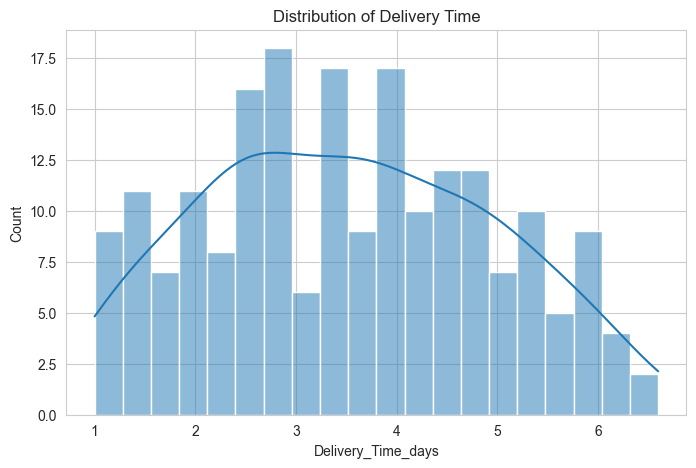

In [34]:
import os

os.makedirs("graphs", exist_ok=True)   # Folder create karega agar nahi hai

plt.figure(figsize=(8,5))
sns.histplot(df["Delivery_Time_days"], bins=20, kde=True)

plt.title("Distribution of Delivery Time")
plt.savefig("graphs/delivery_time_distribution.png")
plt.show()

In [40]:
# Shipment Volume

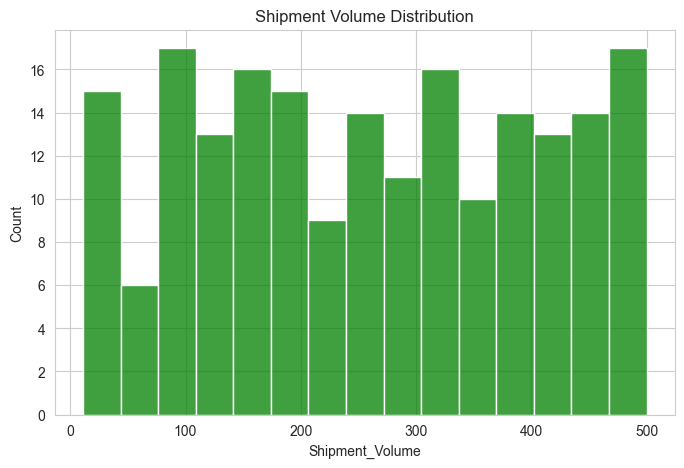

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(df["Shipment_Volume"],bins=15,color="green")

plt.title("Shipment Volume Distribution")

plt.savefig("graphs/shipment_volume.png")

plt.show()

In [42]:
# Transpotation Cost

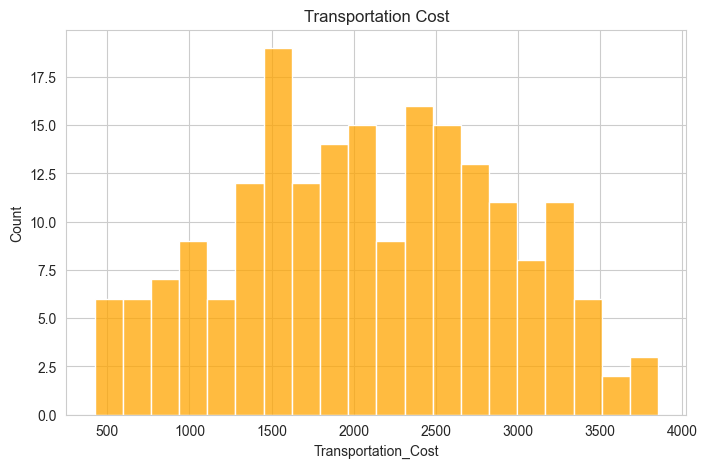

In [43]:
plt.figure(figsize=(8,5))

sns.histplot(df["Transportation_Cost"],bins=20,color="orange")

plt.title("Transportation Cost")

plt.savefig("graphs/transport_cost.png")

plt.show()

In [44]:
# Correlation Heatmap

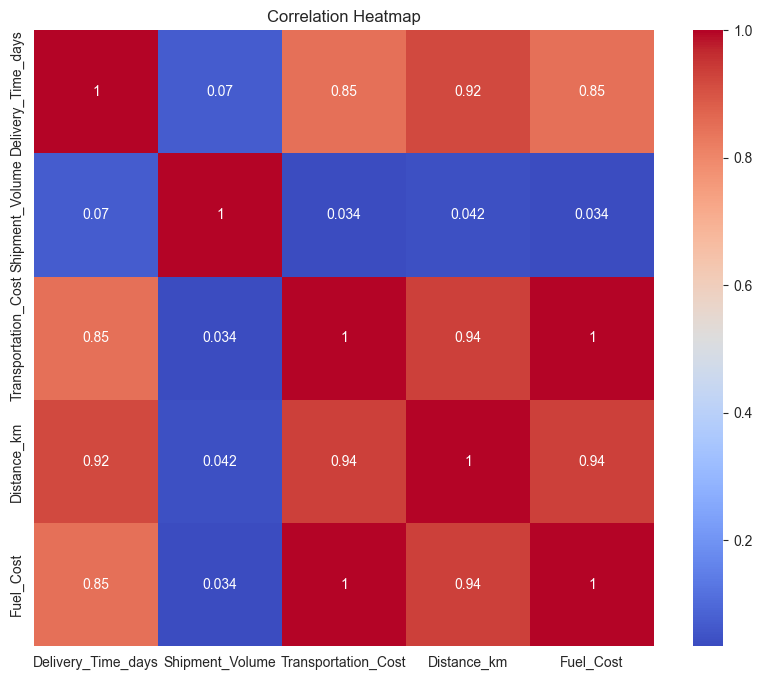

In [45]:
plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("graphs/correlation_heatmap.png")

plt.show()

In [46]:
# Transportation cost Boxplot

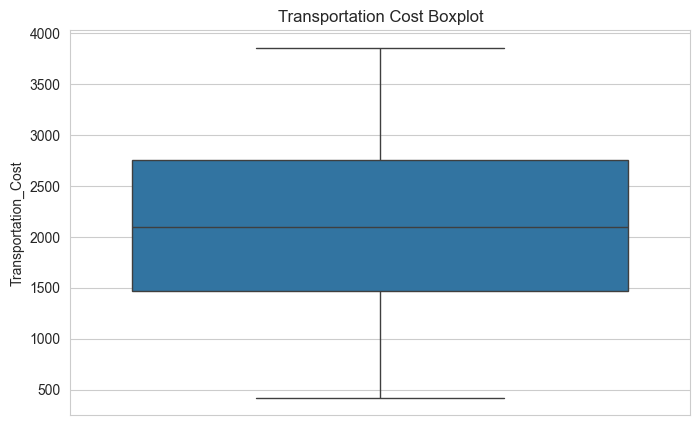

In [47]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Transportation_Cost"])

plt.title("Transportation Cost Boxplot")

plt.savefig("graphs/boxplot_cost.png")

plt.show()

In [48]:
#Region wise shippment

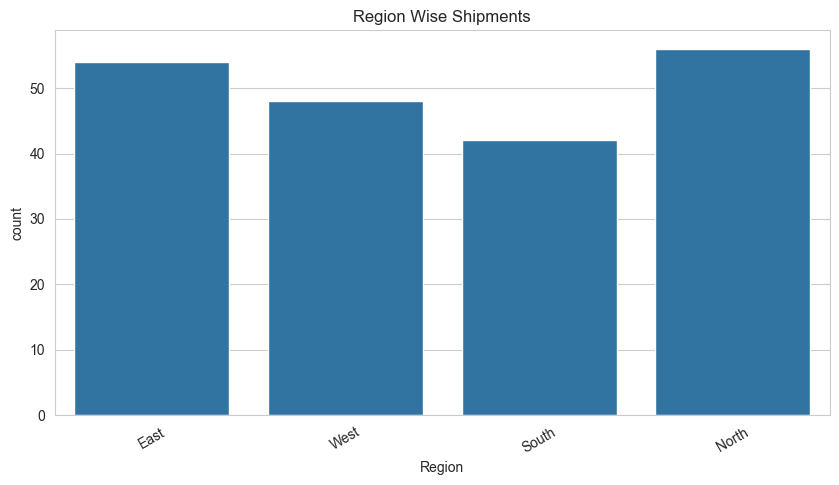

In [49]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,
              x="Region")

plt.xticks(rotation=30)

plt.title("Region Wise Shipments")

plt.savefig("graphs/region_shipments.png")

plt.show()

In [50]:
#Delay Status

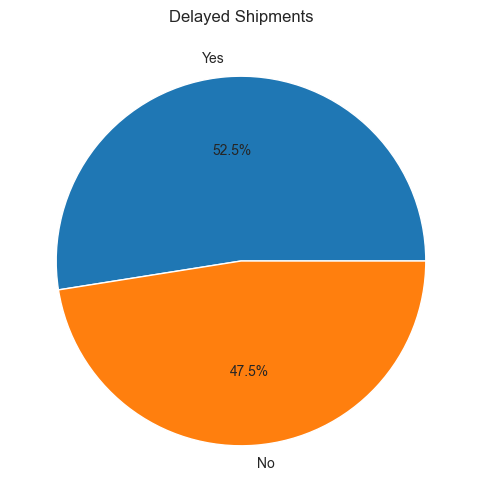

In [55]:
plt.figure(figsize=(6,6))

df["Delay"].value_counts().plot(
kind="pie",
autopct="%1.1f%%")

plt.ylabel("")

plt.title("Delayed Shipments")

plt.savefig("graphs/delay_status.png")

plt.show()

In [61]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Month"] = df["Order_Date"].dt.month_name()

In [56]:
# Monthly Trend

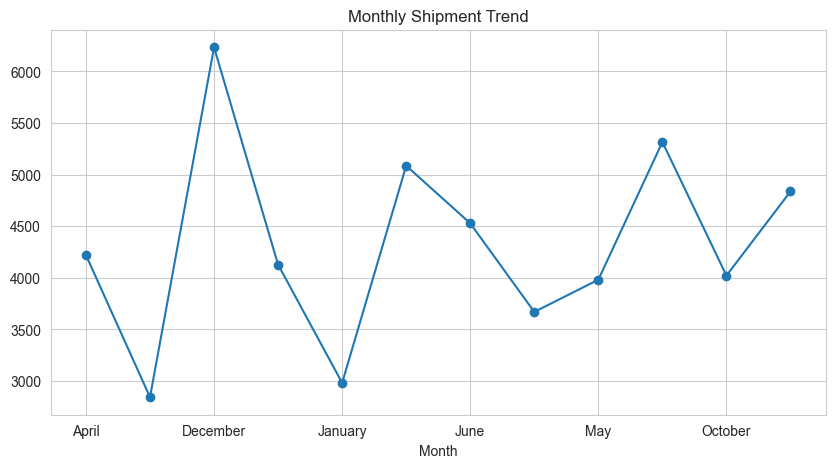

In [62]:
monthly=df.groupby("Month")["Shipment_Volume"].sum()

plt.figure(figsize=(10,5))

monthly.plot(marker="o")

plt.title("Monthly Shipment Trend")

plt.savefig("graphs/monthly_trend.png")

plt.show()

In [63]:
# Average Delivery Time By Region

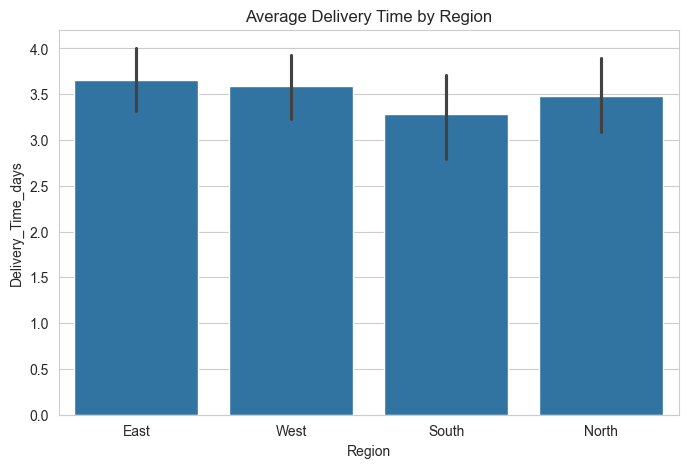

In [65]:
plt.figure(figsize=(8,5))

sns.barplot(
data=df,
x="Region",
y="Delivery_Time_days")

plt.title("Average Delivery Time by Region")

plt.show()

In [66]:
# Cost VS Delivery Time

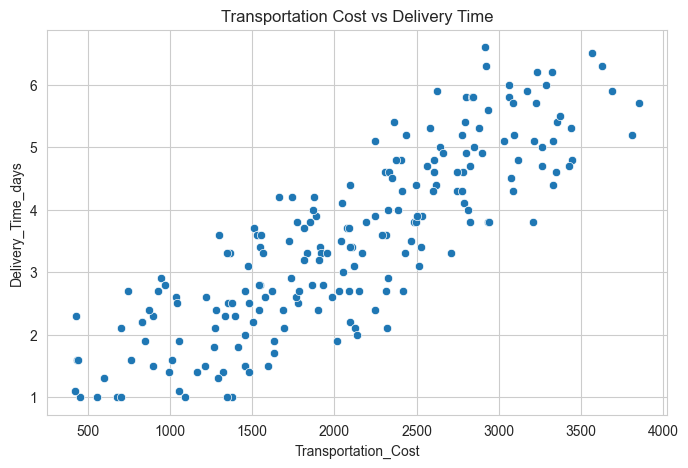

In [69]:
plt.figure(figsize=(8,5))

sns.scatterplot(
data=df,
x="Transportation_Cost",
y="Delivery_Time_days")

plt.title("Transportation Cost vs Delivery Time")

plt.show()

In [70]:
#Shippment Type Count

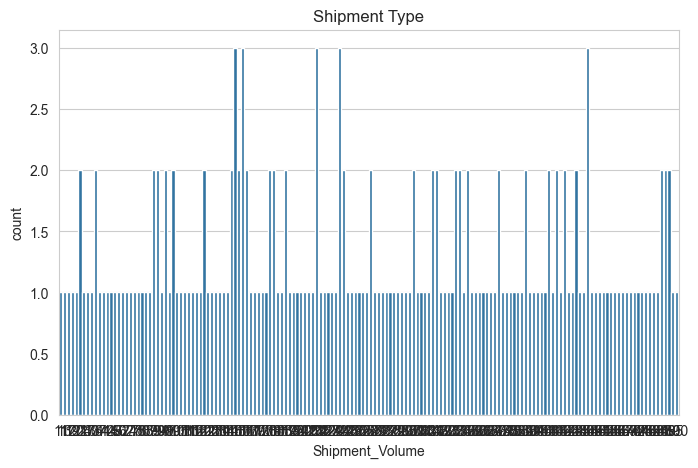

In [72]:
plt.figure(figsize=(8,5))

sns.countplot(
data=df,
x="Shipment_Volume")

plt.title("Shipment Type")

plt.show()

In [73]:
# Vehicle Wise Cost

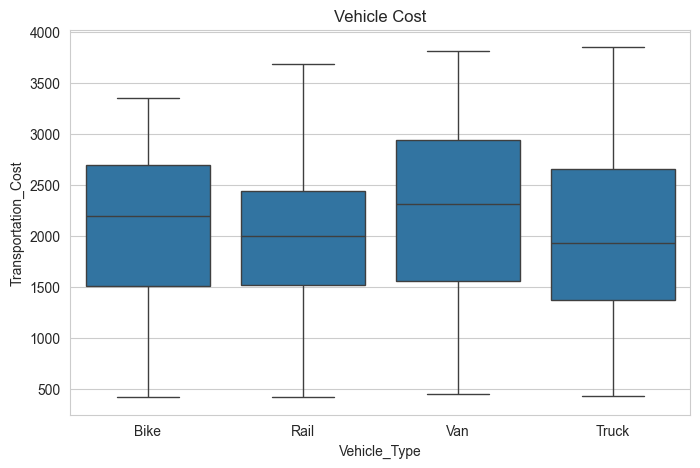

In [74]:
plt.figure(figsize=(8,5))

sns.boxplot(
data=df,
x="Vehicle_Type",
y="Transportation_Cost")

plt.title("Vehicle Cost")

plt.show()

In [75]:
# Top 10 Expensive Shipment

In [76]:
top=df.nlargest(
10,
"Transportation_Cost")

print(top)

    Shipment_ID Order_Date  Delivery_Time_days  Shipment_Volume  \
39      SHP0040 2026-03-18                 5.7              193   
154     SHP0155 2026-05-10                 5.2              373   
168     SHP0169 2026-11-23                 5.9              265   
193     SHP0194 2026-04-18                 6.3              369   
37      SHP0038 2026-09-27                 6.5              489   
7       SHP0008 2026-11-11                 4.8               21   
161     SHP0162 2026-11-09                 5.3               96   
80      SHP0081 2026-03-12                 4.7              242   
157     SHP0158 2026-10-20                 5.5              396   
93      SHP0094 2026-09-19                 5.4              363   

     Transportation_Cost  Distance_km Vehicle_Type Region  Fuel_Cost Delay  \
39                3854.4         1488        Truck  South     963.60    No   
154               3811.4         1488          Van   West     952.85   Yes   
168               3691.2    

In [77]:
#Delayed Shipment Percentage

In [78]:
delay=df["Delay"].value_counts(normalize=True)*100

print(delay)

Delay
Yes    52.5
No     47.5
Name: proportion, dtype: float64


In [79]:
# Region Performance

In [81]:
region=df.groupby("Region").agg({

"Transportation_Cost":"mean",

"Delivery_Time_days":"mean",

"Shipment_Volume":"sum"

})

print(region)

        Transportation_Cost  Delivery_Time_days  Shipment_Volume
Region                                                          
East            2140.259259            3.659259            13895
North           2058.103571            3.480357            14255
South           1983.961905            3.278571            11116
West            2126.816667            3.585417            12577


In [82]:
# Save Summery

In [85]:
summary=df.describe()

summary.to_csv("Summary.csv")